# Intensity vs force
Measures mean intensity of a kymograph within specified force ranges.  Requires a binarised mask image to denote tether region in each image (suffixed with "_mask").

In [1]:
# Importing libraries
from imageio.v3 import imread, imwrite
from lumicks import pylake

import csv
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# Parameters
input_path = "./examples/input/" # Path to folder containing images to process
output_path = "./examples/output/" # Path to folder in which to save output
channel = 0 # Channel to process
force_points = range(5,70,5) # A list containing the central force for each measurement (in pN units)
force_range = 5 # The width of each force measurement (in pN units)

In [ ]:
# Defining process that will be applied to each scan
def process(input_path, output_path, name, file_idx):
    # Reading .h5 file ahd kymograph    
    pylake_file = pylake.File(f"{input_path}/{name}")
    kymo = next(iter(pylake_file.kymos.values()))
    
    # Getting forces
    line_timestamp_ranges = kymo.line_timestamp_ranges()
    forces = pylake_file.downsampled_force2x.downsampled_over(line_timestamp_ranges).data
    
    # Getting kymograph image
    kymo_image = kymo.get_image()[:,0:len(forces),channel]
    
    # Loading kymograph mask
    mask_image = imread(f"{input_path}/{name[:-3]}_mask.tif")[:,0:len(forces)]
    active_timepoints = [np.sum(mask_image, axis=0) > 0]
    
    # For each specified force range, getting the pixels within the mask
    # Also, storing a labelled mask showing the pixels used
    intensities = {}
    label_mask = np.zeros(mask_image.shape)
    first_force = 0
    colour = plt.cm.tab10(file_idx)
    for i, force_point in enumerate(force_points):       
        # Identifying timepoints within the current force range and measuring their mean intensity 
        curr_mask = mask_image.copy()
        curr_mask[:,forces<force_point-force_range/2] = 0
        curr_mask[:,forces>=force_point+force_range/2] = 0
        curr_mask[:,not active_timepoints] = 0
        label_mask[curr_mask>0] = i+1
        
        mean_intensity = np.mean(kymo_image[curr_mask>0])
        
        # Getting force at first timepoint to use as a reference
        if i == 0:
            first_force = mean_intensity
        
        norm_intensity = 100*mean_intensity/first_force
            
        intensities[force_point] = [mean_intensity,norm_intensity, force_point-force_range/2, force_point+force_range/2]
    
        plt.plot(force_point, norm_intensity, "o", color=colour)
    
    imwrite(f"{output_path}/{name[:-3]}_label_mask.tif", label_mask)
    
    with open(f"{output_path}/{name[:-3]}_intensities.csv", 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Force","Intensity","Relative intensity (%)","Min force (pN)", "Max force (pN)"])
        for force, intensity in intensities.items():
            writer.writerow([force,intensity[0],intensity[1],intensity[2],intensity[3]])

Processing: 20240819-150426 Kymograph 5.h5


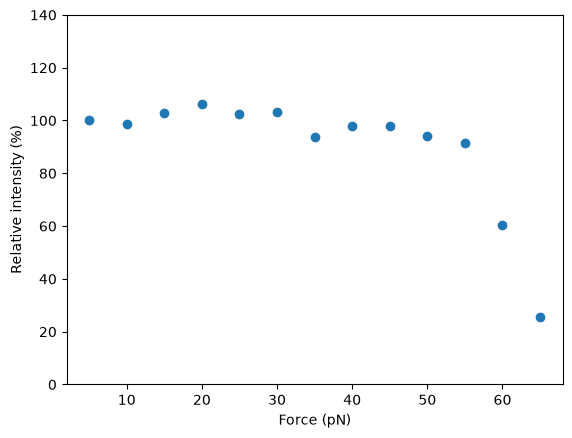

In [4]:
# Batch processing all h5 files in input folder
fig = plt.figure()

file_idx = 0
for name in os.listdir(input_path):
    if os.path.splitext(name)[1] == ".h5":
        print(f"Processing: {name}")
        process(input_path, output_path, name, file_idx)
        file_idx += 1

plt.ylim(0,140)
plt.xlabel("Force (pN)")
plt.ylabel("Relative intensity (%)")    
plt.savefig(f"{output_path}/Intensity_vs_force.png")
plt.savefig(f"{output_path}/Intensity_vs_force.svg")
    